# GMU-GNN Static–Dynamic Crime Forecasting

This notebook preserves the original data loading, feature extraction, smoothing,
normalization, temporal split, node split utilities, and PyG datasets. Only the
model and post-model analyses are replaced.

The model uses the established **Gated Multimodal Unit (GMU)** to fuse static
socioeconomic features and a dynamic crime window at every node. The resulting
joint node representation is passed to a standard graph neural network.


## Architecture

For node $i$ at window $t$:

$$
\mathbf{h}^{s}_{i}=\tanh(W_s\mathbf{x}^{s}_{i}+b_s),\qquad
\mathbf{h}^{d}_{i,t}=\tanh(W_d\mathbf{x}^{d}_{i,t}+b_d),
$$

$$
\mathbf{z}_{i,t}=\sigma\left(W_z[\mathbf{x}^{s}_{i}\Vert
\mathbf{x}^{d}_{i,t}]+b_z\right),
$$

$$
\mathbf{h}^{GMU}_{i,t}=\mathbf{z}_{i,t}\odot\mathbf{h}^{s}_{i}
+(1-\mathbf{z}_{i,t})\odot\mathbf{h}^{d}_{i,t}.
$$

$\mathbf{z}_{i,t}$ is a feature-wise gate: values near 1 favor the static
representation and values near 0 favor the dynamic representation. Graph
message passing occurs after GMU fusion, making this an intermediate
feature-fusion GNN baseline rather than fusion inside message construction.


## What remains unchanged

- Static and dynamic feature selection
- Exponential smoothing and log transformation
- Train-only normalization
- Sliding-window dataset construction
- Existing temporal and node-split setup

The replacement section contains the GMU-GNN, leakage-free fixed-epoch training,
evaluation, gate analysis, modality ablation, neighborhood time-series plots,
gradient sensitivity, and embedding visualization.


In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GraphConv
from torch_geometric.data import Data
import optuna
import pandas as pd
import numpy as np
import torch.nn as nn
import os
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.manifold import TSNE


from helper_funcs import *
from plots import *
from models import *
from model_helper_funcs import *
from model_fusion_scratch import *
from torch_geometric.loader import DataLoader


c:\Users\waqar\AppData\Local\pypoetry\Cache\virtualenvs\data-fusion-r9UYRqEp-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration


In [2]:
seed = 42
set_seed(seed)

num_epochs = 50

data_set = "real"         # "real" | "artificial"
type_graph_conv = 'GMU_GraphConv'  # StaticDynamicGNN_hidden "SAGE" | "GCN" | "GAT" | "FWAGCN" | "EFWAGCN" | "GraphConv" |DualGNN | StaticDynamicGNN_adv
architecture = "2_layers"

# if type_graph_conv == 'SAGE':
#     graph_conv = SAGEConv
# elif type_graph_conv == "GCN":
#     graph_conv = GCNConv
# elif type_graph_conv == "GAT":
#     graph_conv = GATConv
# elif type_graph_conv == "FWAGCN":
#     graph_conv = FeatureWiseGraphConv
# elif type_graph_conv == "EFWAGCN":
#     graph_conv = EdgeFeatureAttentionGCN
# elif type_graph_conv == "GraphConv":
#     graph_conv = GraphConv
# elif type_graph_conv == "DualGNN":
#     graph_conv = DualGNN
    
    
model_used = "GMU_GNN_inductive_learning"     

output_folder = f"results/inductive_learning/{model_used}/{type_graph_conv}/{architecture}"
os.makedirs(output_folder, exist_ok=True)

# Load dataset

In [3]:
if data_set == "artificial":
    print("Using artificial dataset")
    name_file_dataset = os.path.join("datasets", "artificial_data_12_clusters_full.csv")
else:
    print("Using real dataset")
    name_file_dataset = "datasets/datasubset_nodes_waqar.csv"

df_nodes = pd.read_csv(name_file_dataset)
df_edges = pd.read_csv("datasets/aristas_subgrafoSPdaily.csv")
edge_index = map_edges_new_index(df_nodes, df_edges)

Using real dataset
tensor([[    573641,     573641,     573643,  ..., 8751085661, 8753316632,
         8795904828],
        [ 465879071,  292424978,  292424978,  ..., 8751085667, 8753316633,
         8795904831]])


d:\data_fusion\helper_funcs.py:50: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  edges_mapeados = df_edges.applymap(lambda x: mapping_dict.get(x, x)).values


edge_index_mapeado ------->  tensor([[    0,     0,     1,  ..., 14575, 14578, 14596],
        [ 5698,  1381,  1381,  ..., 14576, 14579, 14597]])


In [4]:
df_nodes.shape

(14640, 159)

# Label nodes

In [5]:
df_nodes_label = label_crime_nodes(df_nodes, threshold=6)
crime_label_col = "crime_label"
num_nodes = df_nodes_label.shape[0]

In [6]:
# plot_crime_vs_nocrime_ratio(df_nodes_label)

# Extract feature groups

In [7]:
df_nodes_label.columns

Index(['Nodo', '2006.01', '2006.02', '2006.03', '2006.04', '2006.05',
       '2006.06', '2006.07', '2006.08', '2006.09',
       ...
       'maiores_de_65_anos_taxa', 'Pontos_de_onibus', 'Estacao_de_metro',
       'Estacao_de_trem', 'Terminal_de_onibus', 'Favela_proxima', 'lat',
       'long', 'total_crimes', 'crime_label'],
      dtype='object', length=161)

In [8]:
dynamic_cols = [col for col in df_nodes_label.columns if re.match(r'^\d{4}\.\d{2}$', col)]
dynamic_dt = df_nodes_label[dynamic_cols]

cols_to_drop = dynamic_cols + ['Nodo', 'Pontos_de_onibus', 'lat', 'long', 'total_crimes', 'crime_label']
static_dt = df_nodes_label.drop(columns=cols_to_drop)

In [9]:
crime_label_col = df_nodes_label['crime_label']
crime_label_col

0        1
1        1
2        1
3        1
4        0
        ..
14635    0
14636    0
14637    0
14638    0
14639    0
Name: crime_label, Length: 14640, dtype: int64

In [10]:
static_dt.shape

(14640, 11)

# Normalize features


# Smooth dynamic data

In [11]:
dynamic_dt_smooth = dynamic_dt.apply(lambda row: row.ewm(alpha=0.1).mean(), axis=1)
dynamic_dt_smooth_log = np.log1p(np.array(dynamic_dt_smooth))

# global_min = dynamic_dt_smooth_log.min().min()
# global_max = dynamic_dt_smooth_log.max().max()
# dynamic_dt_norm = pd.DataFrame((dynamic_dt_smooth_log - global_min) / (global_max - global_min))

dynamic_dt_smooth_log = pd.DataFrame(dynamic_dt_smooth_log)
static_dt = pd.DataFrame(static_dt)

# scaler = MinMaxScaler()

# static_dt_norm = pd.DataFrame(scaler.fit_transform(static_dt))

# Convert to tensors

In [12]:
dynamic_tensor = torch.tensor(dynamic_dt_smooth_log.values, dtype=torch.float32)
dynamic_tensor = torch.nan_to_num(dynamic_tensor, nan=0.0)

static_tensor = torch.tensor(static_dt.values, dtype=torch.float32)
static_tensor = torch.nan_to_num(static_tensor, nan=0.0)

In [13]:
print(dynamic_tensor.shape)
print(static_tensor.shape)

torch.Size([14640, 144])
torch.Size([14640, 11])


# Sliding Window approach

In [14]:
# # Time split
TRAIN_END = 100
T = dynamic_tensor.size(1)
W = 5

# train_dataset = CrimeWindowPyGDataset(
# # train_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=0,
#     end_t=TRAIN_END
# )

# test_dataset = CrimeWindowPyGDataset(
# # test_dataset = CrimeWindowDataset(
#     static_tensor, dynamic_tensor, edge_index,
#     window_size=W,
#     start_t=TRAIN_END,
#     end_t=T
# )

# Inductive Learning

In [15]:
import torch

def filter_and_reindex(data, allowed_nodes):

    # ---- Step 1: mask nodes ----
    mask = torch.isin(data.node_ids, allowed_nodes)

    if mask.sum() == 0:
        return None

    # ---- Step 2: filter node features ----
    new_x_static = data.x_static[mask]
    new_x_dynamic = data.x_dynamic[mask]
    new_y = data.y[mask]

    # IMPORTANT: keep original node ids temporarily
    old_node_ids = data.node_ids[mask]

    # ---- Step 3: create mapping old → new index ----
    # Example: {5:0, 10:1, 20:2}
    unique_nodes = old_node_ids
    mapping = {int(old_id): i for i, old_id in enumerate(unique_nodes)}

    # ---- Step 4: filter edges ----
    src, dst = data.edge_index

    edge_mask = torch.isin(src, old_node_ids) & torch.isin(dst, old_node_ids)

    src = src[edge_mask]
    dst = dst[edge_mask]

    # ---- Step 5: reindex edges ----
    new_src = torch.tensor([mapping[int(s)] for s in src])
    new_dst = torch.tensor([mapping[int(d)] for d in dst])

    new_edge_index = torch.stack([new_src, new_dst], dim=0)

    # ---- Step 6: create new node ids (0...N-1) ----
    new_node_ids = torch.arange(len(unique_nodes))

    # ---- Step 7: update time_id ----
    new_time_id = data.time_id[mask]

    # ---- Step 8: return new Data ----
    new_data = data.clone()

    new_data.x_static = new_x_static
    new_data.x_dynamic = new_x_dynamic
    new_data.y = new_y
    new_data.edge_index = new_edge_index
    new_data.node_ids = new_node_ids   # ✅ reindexed
    new_data.time_id = new_time_id
    new_data.num_nodes = len(new_node_ids)

    return new_data

from torch.utils.data import Dataset

class InductiveWrapperDataset(Dataset):
    def __init__(self, base_dataset, allowed_nodes):
        self.base_dataset = base_dataset
        self.allowed_nodes = allowed_nodes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):

        data = self.base_dataset[idx]

        new_data = filter_and_reindex(data, self.allowed_nodes)

        # Handle rare empty case
        if new_data is None:
            return self.__getitem__((idx + 1) % len(self))

        return new_data
    
    import numpy as np

def split_nodes(num_nodes, train_ratio=0.8, seed=42):
    np.random.seed(seed)

    nodes = np.arange(num_nodes)
    np.random.shuffle(nodes)

    split = int(train_ratio * num_nodes)

    train_nodes = torch.tensor(nodes[:split])
    test_nodes = torch.tensor(nodes[split:])

    return train_nodes, test_nodes

## Split nodes

In [16]:
train_nodes, test_nodes = split_nodes(static_tensor.shape[0])

## Compute normalization ONLY from TRAIN

Dynamic normalization

In [17]:
train_dynamic = dynamic_tensor[train_nodes][:, :TRAIN_END]

min_val = train_dynamic.min()
max_val = train_dynamic.max()

dynamic_tensor_norm = (dynamic_tensor - min_val) / (max_val - min_val + 1e-8)

In [18]:
dynamic_tensor.max()

tensor(3.8104)

Static normalization

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_static = static_tensor[train_nodes]

scaler.fit(train_static)

static_tensor_norm = torch.tensor(
    scaler.transform(static_tensor),
    dtype=torch.float32
)

Temporal Split

In [20]:
train_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=0,
    end_t=TRAIN_END
)

test_dataset = CrimeWindowPyGDataset(
    static_tensor_norm,
    dynamic_tensor_norm,
    edge_index,
    window_size=W,
    start_t=TRAIN_END,
    end_t=T
)

# Inductive Split on nodes

In [21]:

# train_dataset = InductiveWrapperDataset(train_dataset, train_nodes)
# test_dataset = InductiveWrapperDataset(test_dataset, test_nodes)

In [22]:
sample = train_dataset[0]

print(sample.x_static.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 11])
tensor(14639) 14640


In [23]:
sample = test_dataset[0]

print(sample.x_dynamic.shape)
print(sample.edge_index.max(), sample.num_nodes)

torch.Size([14640, 5])
tensor(14639) 14640


# GMU fusion and graph model

The GMU is applied independently at every node and time window. Its fused
representation is then propagated over the existing street graph with
`GraphConv`. This is the clean GMU-GNN baseline to compare with fusion inside
your custom message function.


In [27]:
import copy
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GraphConv


class GatedMultimodalUnit(nn.Module):
    """Feature-wise GMU for static and dynamic node modalities."""

    def __init__(self, static_dim, dynamic_dim, hidden_dim):
        super().__init__()
        self.static_encoder = nn.Linear(static_dim, hidden_dim)
        self.dynamic_encoder = nn.Linear(dynamic_dim, hidden_dim)
        self.gate_layer = nn.Linear(static_dim + dynamic_dim, hidden_dim)
        self.reset_parameters()

    def reset_parameters(self):
        for layer in (self.static_encoder, self.dynamic_encoder, self.gate_layer):
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, x_static, x_dynamic):
        h_static = torch.tanh(self.static_encoder(x_static))
        h_dynamic = torch.tanh(self.dynamic_encoder(x_dynamic))
        gate_static = torch.sigmoid(
            self.gate_layer(torch.cat([x_static, x_dynamic], dim=-1))
        )
        h_fused = gate_static * h_static + (1.0 - gate_static) * h_dynamic
        return h_fused, gate_static, h_static, h_dynamic


class GMUGraphForecastModel(nn.Module):
    def __init__(self, static_dim, dynamic_dim, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.gmu = GatedMultimodalUnit(static_dim, dynamic_dim, hidden_dim)
        self.conv1 = GraphConv(hidden_dim, hidden_dim)
        # self.conv2 = GraphConv(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        # self.norm2 = nn.LayerNorm(hidden_dim)
        self.dropout = dropout
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_static, x_dynamic, edge_index, return_details=False):
        h_gmu, gate, h_static, h_dynamic = self.gmu(x_static, x_dynamic)

        h = self.conv1(h_gmu, edge_index)
        h = self.norm1(F.relu(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        # h = self.conv2(h, edge_index)
        # h = self.norm2(F.relu(h))

        prediction = self.regressor(h).squeeze(-1)
        if return_details:
            return prediction, h, {
                "gate": gate,
                "h_static": h_static,
                "h_dynamic": h_dynamic,
                "h_gmu": h_gmu,
            }
        return prediction, h


# Model initialization


In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
S = static_tensor.size(1)

model = GMUGraphForecastModel(
    static_dim=S,
    dynamic_dim=W,
    hidden_dim=64,
    dropout=0.2,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(model)
print("Device:", device)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


GMUGraphForecastModel(
  (gmu): GatedMultimodalUnit(
    (static_encoder): Linear(in_features=11, out_features=64, bias=True)
    (dynamic_encoder): Linear(in_features=5, out_features=64, bias=True)
    (gate_layer): Linear(in_features=16, out_features=64, bias=True)
  )
  (conv1): GraphConv(64, 64)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (regressor): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Device: cpu
Trainable parameters: 19073


# Validation set

In [53]:
from torch.utils.data import Subset

# Chronological validation is taken only from the existing training windows.
# The untouched test_dataset is never used for checkpoint selection.
validation_fraction = 0.20
num_development_windows = len(train_dataset)
num_validation_windows = max(1, int(np.ceil(validation_fraction * num_development_windows)))
validation_start = num_development_windows - num_validation_windows

fit_dataset = Subset(train_dataset, range(0, validation_start))
validation_dataset = Subset(train_dataset, range(validation_start, num_development_windows))

train_loader = DataLoader(fit_dataset, batch_size=1, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Fit windows:", len(fit_dataset))
print("Validation windows:", len(validation_dataset))
print("Untouched test windows:", len(test_dataset))


Fit windows: 76
Validation windows: 19
Untouched test windows: 39


# Training

Because the supplied preprocessing creates only training and test datasets,
the model is trained for the configured fixed number of epochs. The test set is
not used for early stopping or checkpoint selection.


In [54]:
def _move_batch(data, device):
    return data.to(device)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    static_gate_sum = 0.0
    gate_elements = 0

    for data in loader:
        data = _move_batch(data, device)
        optimizer.zero_grad()
        prediction, _, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)
        loss = criterion(prediction, target)
        loss.backward()
        optimizer.step()

        n = target.numel()
        total_loss += loss.item() * n
        total_nodes += n
        static_gate_sum += details["gate"].detach().sum().item()
        gate_elements += details["gate"].numel()

    return total_loss / max(total_nodes, 1), static_gate_sum / max(gate_elements, 1)

@torch.no_grad()
def evaluate_validation(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_nodes = 0

    static_gate_sum = 0.0
    gate_elements = 0

    for data in loader:
        data = _move_batch(
            data,
            device
        )

        prediction, _, details = model(
            data.x_static,
            data.x_dynamic,
            data.edge_index,
            return_details=True,
        )

        target = data.y.float().view_as(
            prediction
        )

        loss = criterion(
            prediction,
            target
        )

        n = target.numel()

        total_loss += loss.item() * n
        total_nodes += n

        static_gate_sum += (
            details["gate"]
            .detach()
            .sum()
            .item()
        )

        gate_elements += (
            details["gate"].numel()
        )

    mean_validation_loss = (
        total_loss
        / max(total_nodes, 1)
    )

    mean_validation_static_gate = (
        static_gate_sum
        / max(gate_elements, 1)
    )

    return (
        mean_validation_loss,
        mean_validation_static_gate,
    )




In [ ]:
# --------------------------------------------------
# Training configuration
# --------------------------------------------------

max_epochs = 250

patience = 20

# Your MSE values are small. Using 1e-7 prevents
# valid small improvements from being ignored.
min_delta = 1e-7


# --------------------------------------------------
# File used to save the best checkpoint
# --------------------------------------------------

checkpoint_path = (
    "best_gmu_gnn_chronological.pt"
)


# --------------------------------------------------
# Variables used by existing notebook analyses
# --------------------------------------------------

train_loss_history = []

static_gate_history = []


# --------------------------------------------------
# New validation histories
# --------------------------------------------------

validation_loss_history = []

validation_static_gate_history = []


# --------------------------------------------------
# Best-model variables
# --------------------------------------------------

best_validation_loss = float("inf")

best_epoch = 0

best_model_state = None

best_optimizer_state = None

epochs_without_improvement = 0


# --------------------------------------------------
# Training
# --------------------------------------------------

for epoch in range(max_epochs):

    # Train using only the earlier fitting windows.
    (
        train_loss,
        static_gate_mean,
    ) = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    # Evaluate using the chronologically later
    # validation windows.
    (
        validation_loss,
        validation_static_gate_mean,
    ) = evaluate_validation(
        model=model,
        loader=validation_loader,
        criterion=criterion,
        device=device,
    )

    # ----------------------------------------------
    # Save histories
    # ----------------------------------------------

    train_loss_history.append(
        train_loss
    )

    static_gate_history.append(
        static_gate_mean
    )

    validation_loss_history.append(
        validation_loss
    )

    validation_static_gate_history.append(
        validation_static_gate_mean
    )

    # ----------------------------------------------
    # Check for validation improvement
    # ----------------------------------------------

    if (
        validation_loss
        < best_validation_loss - min_delta
    ):
        best_validation_loss = (
            validation_loss
        )

        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        best_optimizer_state = copy.deepcopy(
            optimizer.state_dict()
        )

        epochs_without_improvement = 0

        # Save the current best checkpoint to disk.
        torch.save(
            {
                "model_state_dict": (
                    best_model_state
                ),

                "optimizer_state_dict": (
                    best_optimizer_state
                ),

                "best_epoch": best_epoch,

                "best_validation_loss": (
                    best_validation_loss
                ),

                "train_loss_at_best_epoch": (
                    train_loss
                ),

                "train_loss_history": (
                    train_loss_history.copy()
                ),

                "validation_loss_history": (
                    validation_loss_history.copy()
                ),

                "static_gate_history": (
                    static_gate_history.copy()
                ),

                "validation_static_gate_history": (
                    validation_static_gate_history.copy()
                ),

                "validation_fraction": (
                    validation_fraction
                ),

                "num_fit_windows": (
                    len(fit_dataset)
                ),

                "num_validation_windows": (
                    len(validation_dataset)
                ),
            },
            checkpoint_path,
        )

    else:
        epochs_without_improvement += 1

    # ----------------------------------------------
    # Print progress
    # ----------------------------------------------

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
        or epoch + 1 == max_epochs
    ):
        print(
            f"Epoch {epoch + 1:03d}/"
            f"{max_epochs} | "
            f"Train MSE: "
            f"{train_loss:.8f} | "
            f"Validation MSE: "
            f"{validation_loss:.8f} | "
            f"Best validation MSE: "
            f"{best_validation_loss:.8f} "
            f"(epoch {best_epoch}) | "
            f"Train static gate: "
            f"{static_gate_mean:.4f} | "
            f"Validation static gate: "
            f"{validation_static_gate_mean:.4f} | "
            f"Patience: "
            f"{epochs_without_improvement}/"
            f"{patience}"
        )

    # ----------------------------------------------
    # Early stopping
    # ----------------------------------------------

    if (
        epochs_without_improvement
        >= patience
    ):
        print(
            f"\nEarly stopping at epoch "
            f"{epoch + 1}."
        )

        print(
            f"Best validation MSE: "
            f"{best_validation_loss:.8f} "
            f"at epoch {best_epoch}."
        )

        break

# Training and gate-history plots


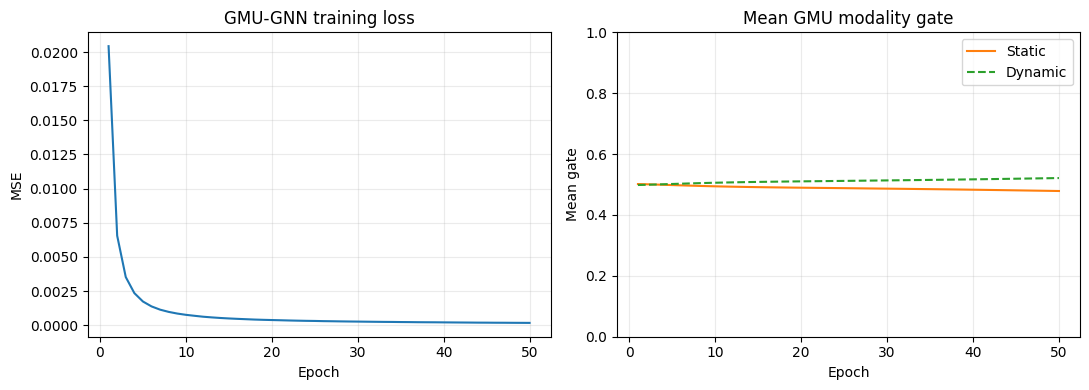

In [30]:
epochs = np.arange(1, len(train_loss_history) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, train_loss_history, color="tab:blue")
axes[0].set(title="GMU-GNN training loss", xlabel="Epoch", ylabel="MSE")
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, static_gate_history, label="Static", color="tab:orange")
axes[1].plot(
    epochs, 1.0 - np.asarray(static_gate_history),
    label="Dynamic", color="tab:green", linestyle="--"
)
axes[1].set(title="Mean GMU modality gate", xlabel="Epoch", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_training_and_gate_history.png"), dpi=300, bbox_inches="tight")
plt.show()


# Test evaluation and collection


In [31]:
@torch.no_grad()
def evaluate_and_collect_gmu(model, loader, device, ablation=None):
    model.eval()
    predictions_per_time = []
    targets_per_time = []
    embeddings_per_time = []
    gates_per_time = []
    node_ids_per_time = []
    time_ids_per_time = []

    for step, data in enumerate(loader):
        data = _move_batch(data, device)
        x_static = data.x_static
        x_dynamic = data.x_dynamic

        if ablation == "static_only":
            x_dynamic = torch.zeros_like(x_dynamic)
        elif ablation == "dynamic_only":
            x_static = torch.zeros_like(x_static)

        prediction, embedding, details = model(
            x_static, x_dynamic, data.edge_index, return_details=True
        )
        target = data.y.float().view_as(prediction)

        n = target.numel()
        node_ids = getattr(data, "node_ids", torch.arange(n, device=device)).reshape(-1)
        time_ids = getattr(data, "time_id", torch.tensor(step, device=device)).reshape(-1)
        if node_ids.numel() == 1 and n > 1:
            node_ids = node_ids.repeat(n)
        if time_ids.numel() == 1 and n > 1:
            time_ids = time_ids.repeat(n)

        predictions_per_time.append(prediction.detach().cpu().numpy())
        targets_per_time.append(target.detach().cpu().numpy())
        embeddings_per_time.append(embedding.detach().cpu())
        gates_per_time.append(details["gate"].detach().cpu())
        node_ids_per_time.append(node_ids.detach().cpu())
        time_ids_per_time.append(time_ids.detach().cpu())

    y_pred = np.concatenate(predictions_per_time)
    y_true = np.concatenate(targets_per_time)
    error = y_pred - y_true
    mse = float(np.mean(error ** 2))
    mae = float(np.mean(np.abs(error)))
    variance = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = float(1.0 - np.sum(error ** 2) / variance) if variance > 0 else float("nan")

    metrics = {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": mae,
        "R2": r2,
    }
    details = {
        "predictions_per_time": predictions_per_time,
        "targets_per_time": targets_per_time,
        "embeddings_per_time": embeddings_per_time,
        "gates_per_time": gates_per_time,
        "gates": torch.cat(gates_per_time, dim=0),
        "node_ids": torch.cat(node_ids_per_time),
        "time_ids": torch.cat(time_ids_per_time),
    }
    return metrics, details


metrics, test_results = evaluate_and_collect_gmu(model, test_loader, device)
preds_per_t = test_results["predictions_per_time"]
targets_per_t = test_results["targets_per_time"]

display(pd.DataFrame([metrics]))
pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"]).to_csv(
    os.path.join(output_folder, "metrics_GMU_GNN.csv"), index=False
)


,MSE,RMSE,MAE,R2
0,0.000132,0.011483,0.006704,0.954551


# GMU modality contribution

The GMU has a feature-wise gate. For summaries, the gate is averaged over the
hidden dimensions. These values describe the model's learned mixing mechanism;
they are not causal importance scores.


Global mean static gate : 0.4784
Global mean dynamic gate: 0.5216


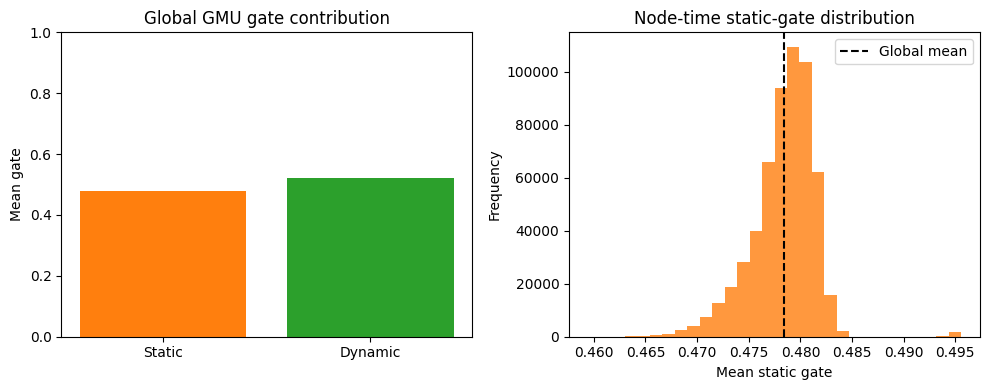

In [32]:
gates = test_results["gates"]                         # [all node-time cases, hidden_dim]
case_static_gate = gates.mean(dim=1)                 # scalar summary per node-time case
global_static_gate = case_static_gate.mean().item()
global_dynamic_gate = 1.0 - global_static_gate

print(f"Global mean static gate : {global_static_gate:.4f}")
print(f"Global mean dynamic gate: {global_dynamic_gate:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Static", "Dynamic"], [global_static_gate, global_dynamic_gate],
            color=["tab:orange", "tab:green"])
axes[0].set(title="Global GMU gate contribution", ylabel="Mean gate", ylim=(0, 1))

axes[1].hist(case_static_gate.numpy(), bins=30, color="tab:orange", alpha=0.8)
axes[1].axvline(global_static_gate, color="black", linestyle="--", label="Global mean")
axes[1].set(title="Node-time static-gate distribution", xlabel="Mean static gate", ylabel="Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_global_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()


# Spatial and temporal gate analysis


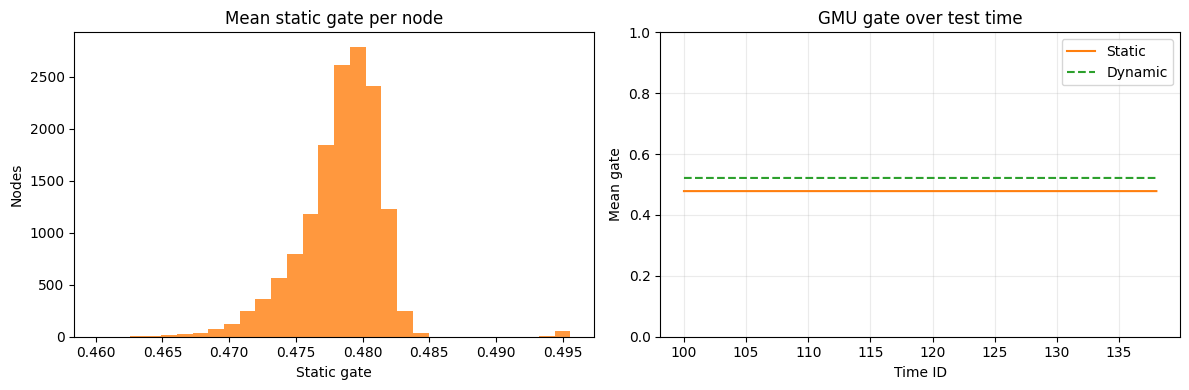

In [33]:
gate_frame = pd.DataFrame({
    "node_id": test_results["node_ids"].numpy(),
    "time_id": test_results["time_ids"].numpy(),
    "static_gate": case_static_gate.numpy(),
})
gate_frame["dynamic_gate"] = 1.0 - gate_frame["static_gate"]

node_gate = gate_frame.groupby("node_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()
time_gate = gate_frame.groupby("time_id", as_index=False)[["static_gate", "dynamic_gate"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(node_gate["static_gate"], bins=30, color="tab:orange", alpha=0.8)
axes[0].set(title="Mean static gate per node", xlabel="Static gate", ylabel="Nodes")

axes[1].plot(time_gate["time_id"], time_gate["static_gate"], label="Static", color="tab:orange")
axes[1].plot(time_gate["time_id"], time_gate["dynamic_gate"], label="Dynamic", color="tab:green", linestyle="--")
axes[1].set(title="GMU gate over test time", xlabel="Time ID", ylabel="Mean gate", ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_spatial_temporal_gate_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

gate_frame.to_csv(os.path.join(output_folder, "gmu_gate_node_time_values.csv"), index=False)


# Representative dynamic-, balanced-, and static-heavy nodes


{'Dynamic-heavy': 11893, 'Balanced': 12949, 'Static-heavy': 12949}


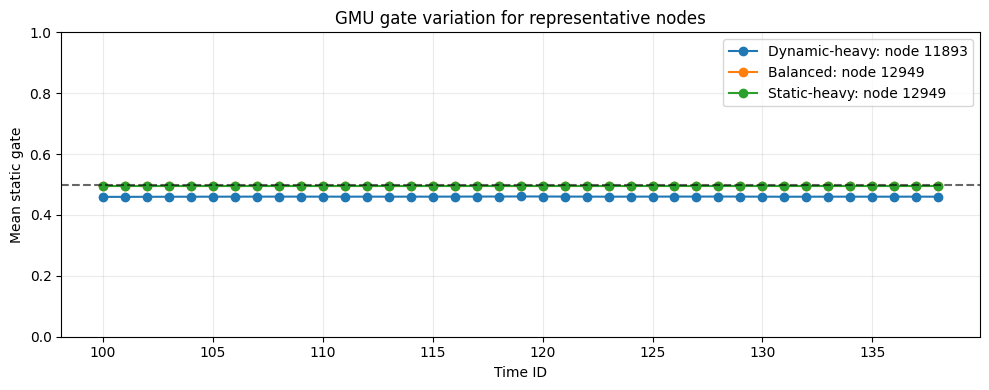

In [34]:
node_gate_sorted = node_gate.sort_values("static_gate").reset_index(drop=True)
dynamic_heavy_node = int(node_gate_sorted.iloc[0]["node_id"])
balanced_node = int(node_gate_sorted.iloc[(node_gate_sorted["static_gate"] - 0.5).abs().argmin()]["node_id"])
static_heavy_node = int(node_gate_sorted.iloc[-1]["node_id"])

selected_nodes = {
    "Dynamic-heavy": dynamic_heavy_node,
    "Balanced": balanced_node,
    "Static-heavy": static_heavy_node,
}
print(selected_nodes)

plt.figure(figsize=(10, 4))
for label, node in selected_nodes.items():
    series = gate_frame[gate_frame["node_id"] == node].sort_values("time_id")
    plt.plot(series["time_id"], series["static_gate"], marker="o", label=f"{label}: node {node}")
plt.axhline(0.5, color="black", linestyle="--", alpha=0.6)
plt.xlabel("Time ID")
plt.ylabel("Mean static gate")
plt.title("GMU gate variation for representative nodes")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_representative_node_gates.png"), dpi=300, bbox_inches="tight")
plt.show()


# Modality ablation

`Static only` zeros the dynamic input, while `Dynamic only` zeros the static
input. The already-trained full model is not retrained; this measures input
ablation sensitivity. For a stronger paper experiment, also train separate
static-only and dynamic-only GNNs from scratch.


,Input,MSE,RMSE,MAE,R2
0,Full GMU,0.000132,0.011483,0.006704,0.954551
1,Static only,0.003846,0.062018,0.030669,-0.325726
2,Dynamic only,0.001425,0.037747,0.021818,0.508900


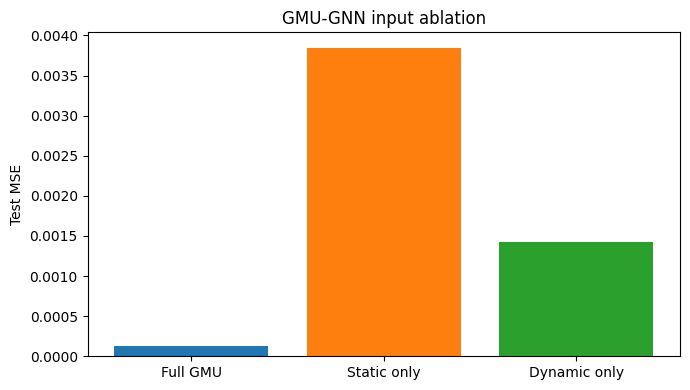

In [35]:
static_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="static_only")
dynamic_metrics, _ = evaluate_and_collect_gmu(model, test_loader, device, ablation="dynamic_only")

ablation_results = pd.DataFrame([
    {"Input": "Full GMU", **metrics},
    {"Input": "Static only", **static_metrics},
    {"Input": "Dynamic only", **dynamic_metrics},
])
display(ablation_results)
ablation_results.to_csv(os.path.join(output_folder, "gmu_ablation_results.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.bar(ablation_results["Input"], ablation_results["MSE"],
        color=["tab:blue", "tab:orange", "tab:green"])
plt.ylabel("Test MSE")
plt.title("GMU-GNN input ablation")
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_ablation_mse.png"), dpi=300, bbox_inches="tight")
plt.show()


# Gradient sensitivity check


In [36]:
def gradient_sensitivity(model, data, device):
    model.eval()
    data = data.to(device)
    x_static = data.x_static.detach().clone().requires_grad_(True)
    x_dynamic = data.x_dynamic.detach().clone().requires_grad_(True)
    prediction, _ = model(x_static, x_dynamic, data.edge_index)
    prediction.mean().backward()
    return {
        "Static mean |gradient|": x_static.grad.abs().mean().item(),
        "Dynamic mean |gradient|": x_dynamic.grad.abs().mean().item(),
    }


gradient_results = gradient_sensitivity(model, next(iter(test_loader)), device)
display(pd.DataFrame([gradient_results]))


,Static mean |gradient|,Dynamic mean |gradient|
0,5.319890e-07,0.000011


# Predicted time-series and neighborhood analysis


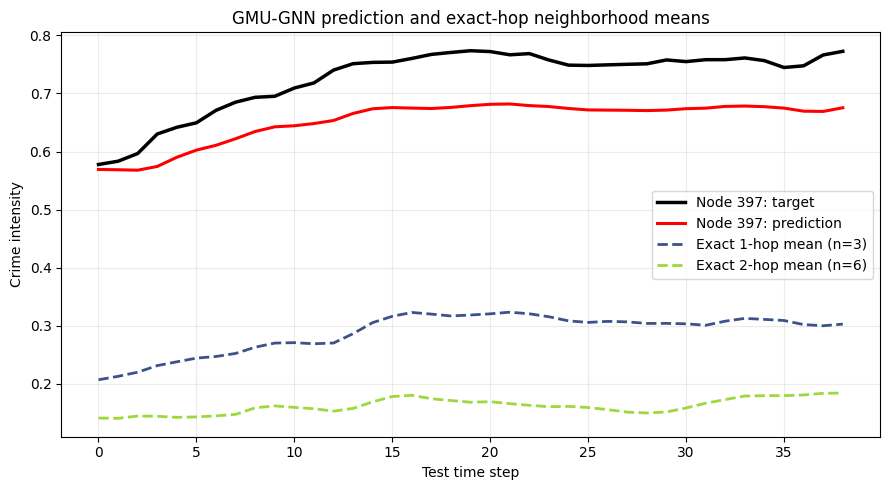

In [37]:
def adjacency_from_edge_index(edge_index, num_nodes):
    adjacency = {i: set() for i in range(num_nodes)}
    src, dst = edge_index.detach().cpu().numpy()
    for u, v in zip(src, dst):
        adjacency[int(u)].add(int(v))
        adjacency[int(v)].add(int(u))
    return adjacency


def exact_hop_nodes(center, adjacency, hop):
    visited = {center}
    frontier = {center}
    for _ in range(hop):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(adjacency.get(node, set()))
        next_frontier -= visited
        visited |= next_frontier
        frontier = next_frontier
    return sorted(frontier)


def plot_neighborhood_prediction(pred_matrix, target_matrix, center_node, adjacency,
                                 max_hop=2, output_path=None):
    time = np.arange(pred_matrix.shape[0])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(time, target_matrix[:, center_node], color="black", linewidth=2.5,
            label=f"Node {center_node}: target")
    ax.plot(time, pred_matrix[:, center_node], color="red", linewidth=2.2,
            label=f"Node {center_node}: prediction")

    colors = plt.cm.viridis(np.linspace(0.25, 0.85, max_hop))
    for hop, color in zip(range(1, max_hop + 1), colors):
        nodes = exact_hop_nodes(center_node, adjacency, hop)
        if nodes:
            mean_series = pred_matrix[:, nodes].mean(axis=1)
            ax.plot(time, mean_series, linestyle="--", linewidth=2, color=color,
                    label=f"Exact {hop}-hop mean (n={len(nodes)})")

    ax.set(xlabel="Test time step", ylabel="Crime intensity",
           title="GMU-GNN prediction and exact-hop neighborhood means")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


pred_matrix = np.stack(preds_per_t)
target_matrix = np.stack(targets_per_t)
sample_graph = test_dataset[0]
adjacency = adjacency_from_edge_index(sample_graph.edge_index, pred_matrix.shape[1])

# Select the node with the highest mean target crime in the test period.
selected_node = int(np.argmax(target_matrix.mean(axis=0)))
plot_neighborhood_prediction(
    pred_matrix, target_matrix, selected_node, adjacency, max_hop=2,
    output_path=os.path.join(output_folder, "gmu_high_crime_node_neighborhood.png")
)


# Prediction scatter and residual analysis


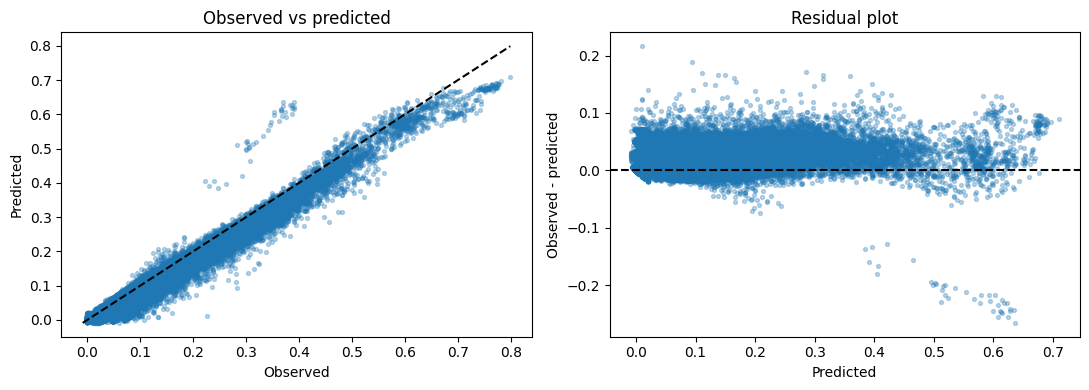

In [38]:
y_true = target_matrix.reshape(-1)
y_pred = pred_matrix.reshape(-1)
residual = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_true, y_pred, s=8, alpha=0.3)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], color="black", linestyle="--")
axes[0].set(title="Observed vs predicted", xlabel="Observed", ylabel="Predicted")

axes[1].scatter(y_pred, residual, s=8, alpha=0.3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(title="Residual plot", xlabel="Predicted", ylabel="Observed - predicted")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_prediction_diagnostics.png"), dpi=300, bbox_inches="tight")
plt.show()


# GMU-GNN embedding projection


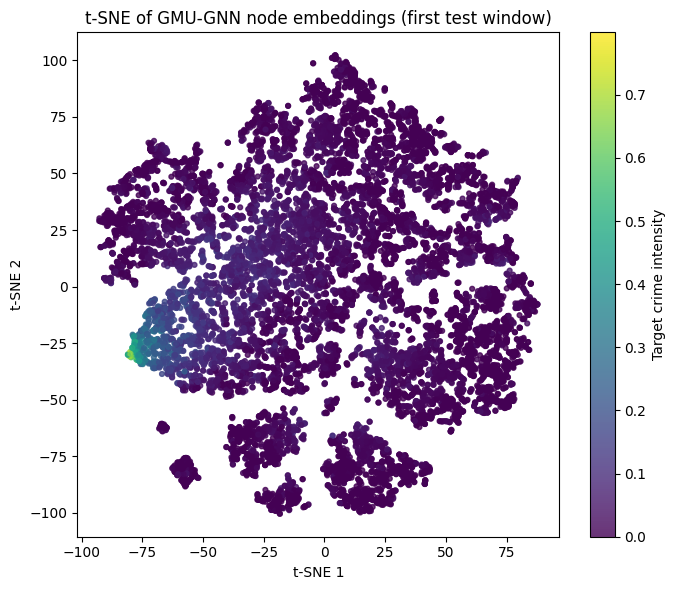

In [39]:
from sklearn.manifold import TSNE

# Use the first test window so that each plotted point corresponds to one node.
embedding = test_results["embeddings_per_time"][0].numpy()
target_first_window = targets_per_t[0]

if embedding.shape[0] >= 3:
    perplexity = min(30, max(2, (embedding.shape[0] - 1) // 3))
    embedding_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=seed,
    ).fit_transform(embedding)

    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(
        embedding_2d[:, 0], embedding_2d[:, 1],
        c=target_first_window, cmap="viridis", s=12, alpha=0.8
    )
    plt.colorbar(scatter, label="Target crime intensity")
    plt.title("t-SNE of GMU-GNN node embeddings (first test window)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(os.path.join(output_folder, "gmu_embedding_tsne.png"), dpi=300, bbox_inches="tight")
    plt.show()

    pd.DataFrame(embedding_2d, columns=["tsne_1", "tsne_2"]).to_csv(
        os.path.join(output_folder, "gmu_embedding_tsne.csv"), index=False
    )
else:
    print("At least three nodes are required for t-SNE.")


# Interpretation notes

- A GMU gate near 1 favors the static latent representation; a gate near 0
  favors the dynamic latent representation.
- The gate is feature-wise, so its mean is only a compact summary.
- Gate values are learned mixing coefficients, not causal modality effects.
- The ablation experiment complements the gate analysis but does not replace
  separately trained static-only and dynamic-only baselines.
- For fair comparison with your message-level fusion model, use the same graph
  convolution, hidden dimension, optimizer, epochs, and evaluation split.


# Complete GMU–GNN explainability and validation suite

This appendix makes the GMU–GNN baseline analytically consistent with the M11 and original-GMU notebooks wherever the architectures permit a valid comparison. It does **not** alter preprocessing, normalization, dataset construction, model definition, training, or any existing analysis.

## Architectural comparability

| M11 analysis | GMU–GNN equivalent | Eligibility |
|---|---|---|
| Self and neighbor gate health | One upstream GMU gate | Applicable with one shared role |
| Feature-wise gate specialization | GMU feature-wise specialization | Applicable |
| Gate–crime association | GMU gate–crime association | Applicable |
| Effective activation contribution | GMU effective activation contribution before GraphConv | Applicable |
| Self-versus-neighbor gate separation | None | **Not defined: GMU–GNN has one gate before propagation** |
| Spatial/temporal stability | GMU node/time stability | Applicable |
| Gate–error relationship | GMU gate–error relationship | Applicable |
| Gate intervention | Single-gate interventions | Applicable |
| Input permutation importance | Static/dynamic input permutation | Applicable |
| Time-cluster bootstrap | Single-gate bootstrap | Applicable |
| Graph reliance | Edge-removal intervention | Applicable because GraphConv uses the graph |

Unlike original GMU-only, this model genuinely uses `edge_index` through `GraphConv`. Its exact-hop plot can therefore be discussed as neighborhood context. Nevertheless, it has no separate neighbor gate: the same fused GMU representation is supplied to both the GraphConv root and neighborhood operations.

### Split audit

The supplied notebook constructs node-restricted training and test datasets through `InductiveWrapperDataset`. This supports an unseen-node evaluation only if `train_nodes` and `test_nodes` are disjoint and every graph tensor is correctly relabeled by the wrapper. The audit cell below verifies the observable node-ID separation without changing preprocessing.

In [40]:
def audit_inductive_split(train_dataset, test_dataset):
    def collect_ids(dataset):
        collected = []
        for data in dataset:
            ids = getattr(data, "node_ids", None)
            if ids is not None:
                collected.append(torch.as_tensor(ids).reshape(-1).cpu())
        return torch.unique(torch.cat(collected)) if collected else None

    train_ids = collect_ids(train_dataset)
    test_ids = collect_ids(test_dataset)

    if train_ids is None or test_ids is None:
        print("Node IDs are unavailable; automatic inductive-overlap verification cannot be performed.")
        return None

    overlap = np.intersect1d(train_ids.numpy(), test_ids.numpy())
    result = pd.DataFrame([{
        "unique_train_nodes": len(train_ids),
        "unique_test_nodes": len(test_ids),
        "overlapping_node_ids": len(overlap),
        "node_inductive_split": len(overlap) == 0,
    }])
    display(result)
    if len(overlap):
        print("Warning: the train and test node-ID sets overlap; this is not strict unseen-node evaluation.")
    else:
        print("No train/test node-ID overlap was detected.")
    return result


inductive_split_audit = audit_inductive_split(train_dataset, test_dataset)


,unique_train_nodes,unique_test_nodes,overlapping_node_ids,node_inductive_split
0,14640,14640,14640,False


## A. GMU–GNN graph-embedding projection

The existing t-SNE section immediately above this appendix already provides the counterpart to M11’s embedding projection, so it is not duplicated. In this model, the collected embedding is the output of `GraphConv`, not the raw pre-graph GMU fusion vector. Therefore, its local t-SNE structure reflects both modality fusion and graph propagation. t-SNE is an exploratory visualization, not evidence of prediction quality or cluster accuracy.

## B. Rich node-time GMU explainability collection

This cell collects the exact feature-wise GMU gate, both `tanh` modality candidates,
their gated activation magnitudes before GraphConv, graph-informed predictions, errors, node IDs and time IDs. The same
definitions are then reused by all remaining analyses.

In [41]:
import contextlib
import math
import warnings

try:
    from scipy.stats import pearsonr, spearmanr
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    warnings.warn("SciPy is unavailable; p-values will be skipped.")


def _expand_gmu_metadata(value, n, fallback, device):
    if value is None:
        value = torch.as_tensor(fallback, device=device)
    value = value.reshape(-1)
    if value.numel() == 1 and n > 1:
        value = value.repeat(n)
    if value.numel() != n:
        raise ValueError(f"Metadata length {value.numel()} does not match node count {n}.")
    return value


@torch.no_grad()
def collect_rich_gmu_explainability(model, loader, device):
    model.eval()
    frames, gate_vectors = [], []
    for step, data in enumerate(loader):
        data = data.to(device)
        prediction, embedding, details = model(
            data.x_static, data.x_dynamic, data.edge_index, return_details=True
        )
        prediction = prediction.reshape(-1)
        target = data.y.float().view_as(prediction)
        n = prediction.numel()
        node_ids = _expand_gmu_metadata(
            getattr(data, "node_ids", None), n, torch.arange(n, device=device), device
        )
        time_ids = _expand_gmu_metadata(getattr(data, "time_id", None), n, step, device)

        gate = details["gate"]
        h_static = details["h_static"]
        h_dynamic = details["h_dynamic"]
        static_component = gate * h_static
        dynamic_component = (1.0 - gate) * h_dynamic
        static_mag = torch.linalg.vector_norm(static_component, dim=1)
        dynamic_mag = torch.linalg.vector_norm(dynamic_component, dim=1)
        static_prop = static_mag / (static_mag + dynamic_mag + 1e-12)

        frames.append(pd.DataFrame({
            "node_id": node_ids.cpu().numpy(),
            "time_id": time_ids.cpu().numpy(),
            "input_crime": data.x_dynamic.mean(dim=1).cpu().numpy(),
            "target_crime": target.cpu().numpy(),
            "prediction": prediction.cpu().numpy(),
            "residual": (target - prediction).cpu().numpy(),
            "absolute_error": (target - prediction).abs().cpu().numpy(),
            "gmu_static_gate": gate.mean(dim=1).cpu().numpy(),
            "gmu_dynamic_gate": (1.0 - gate).mean(dim=1).cpu().numpy(),
            "static_activation": static_mag.cpu().numpy(),
            "dynamic_activation": dynamic_mag.cpu().numpy(),
            "static_activation_proportion": static_prop.cpu().numpy(),
            "dynamic_activation_proportion": (1.0-static_prop).cpu().numpy(),
        }))
        gate_vectors.append(gate.cpu())
    return pd.concat(frames, ignore_index=True), torch.cat(gate_vectors).numpy()


gmu_explain_frame, gmu_gate_vectors = collect_rich_gmu_explainability(
    model, test_loader, device
)
print("Explainability cases:", len(gmu_explain_frame))
print("GMU gate vector shape:", gmu_gate_vectors.shape)
display(gmu_explain_frame.head())
gmu_explain_frame.to_csv(os.path.join(output_folder, "gmu_rich_explainability_cases.csv"), index=False)

Explainability cases: 570960
GMU gate vector shape: (570960, 64)


,node_id,time_id,input_crime,target_crime,prediction,residual,absolute_error,gmu_static_gate,gmu_dynamic_gate,static_activation,dynamic_activation,static_activation_proportion,dynamic_activation_proportion
0,0,100,0.126909,0.136371,0.116410,0.019962,0.019962,0.475727,0.524273,0.840222,0.301737,0.735773,0.264227
1,1,100,0.109170,0.097192,0.098201,-0.001009,0.001009,0.477308,0.522692,0.784795,0.256345,0.753784,0.246216
2,2,100,0.161374,0.125887,0.132437,-0.006550,0.006550,0.476887,0.523113,0.829720,0.367851,0.692836,0.307164
3,3,100,0.096176,0.097884,0.084579,0.013305,0.013305,0.477896,0.522104,0.855847,0.234910,0.784636,0.215364
4,4,100,0.014133,0.041428,0.017153,0.024275,0.024275,0.476465,0.523535,0.887024,0.079370,0.917870,0.082130


## C. Gate health: variation, entropy and saturation

A global mean near 0.5 is not gate collapse. Collapse is better assessed through
feature-wise variance, case-level variance, entropy, saturation, intervention evidence,
and repeatability across seeds.

,role,global_mean,global_std,case_mean_std,q05,median,q95,minimum,maximum,mean_entropy_0_to_1,fraction_below_0.10,fraction_above_0.90,fraction_near_balanced_0.45_0.55
0,single_GMU_gate,0.4784,0.0699,0.0031,0.374,0.4759,0.5981,0.2078,0.7852,0.9844,0.0,0.0,0.4641


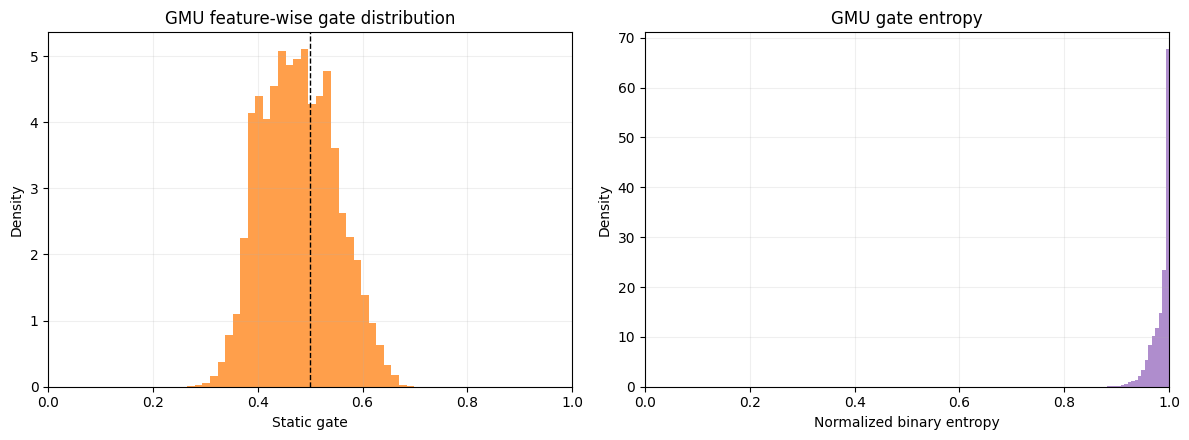

In [42]:
def binary_gate_entropy(gates, eps=1e-8):
    g = np.clip(np.asarray(gates), eps, 1.0-eps)
    return -(g*np.log(g) + (1.0-g)*np.log(1.0-g)) / np.log(2.0)


flat_gate = gmu_gate_vectors.reshape(-1)
case_gate = gmu_gate_vectors.mean(axis=1)
gmu_gate_health = pd.DataFrame([{
    "role": "single_GMU_gate",
    "global_mean": flat_gate.mean(),
    "global_std": flat_gate.std(),
    "case_mean_std": case_gate.std(),
    "q05": np.quantile(flat_gate, 0.05),
    "median": np.median(flat_gate),
    "q95": np.quantile(flat_gate, 0.95),
    "minimum": flat_gate.min(),
    "maximum": flat_gate.max(),
    "mean_entropy_0_to_1": binary_gate_entropy(flat_gate).mean(),
    "fraction_below_0.10": np.mean(flat_gate < 0.10),
    "fraction_above_0.90": np.mean(flat_gate > 0.90),
    "fraction_near_balanced_0.45_0.55": np.mean((flat_gate >= 0.45) & (flat_gate <= 0.55)),
}])
display(gmu_gate_health.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(flat_gate, bins=40, density=True, alpha=0.75, color="tab:orange")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="GMU feature-wise gate distribution", xlabel="Static gate", ylabel="Density", xlim=(0, 1))
axes[1].hist(binary_gate_entropy(flat_gate), bins=40, density=True, alpha=0.75, color="tab:purple")
axes[1].set(title="GMU gate entropy", xlabel="Normalized binary entropy", ylabel="Density", xlim=(0, 1))
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_professional_gate_health.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_health.to_csv(os.path.join(output_folder, "gmu_professional_gate_health.csv"), index=False)

## D. Feature-wise GMU specialization

GMU has an $N\times H$ gate. This analysis checks whether averaging across the 64 latent
dimensions hides opposing static- and dynamic-preferring components.

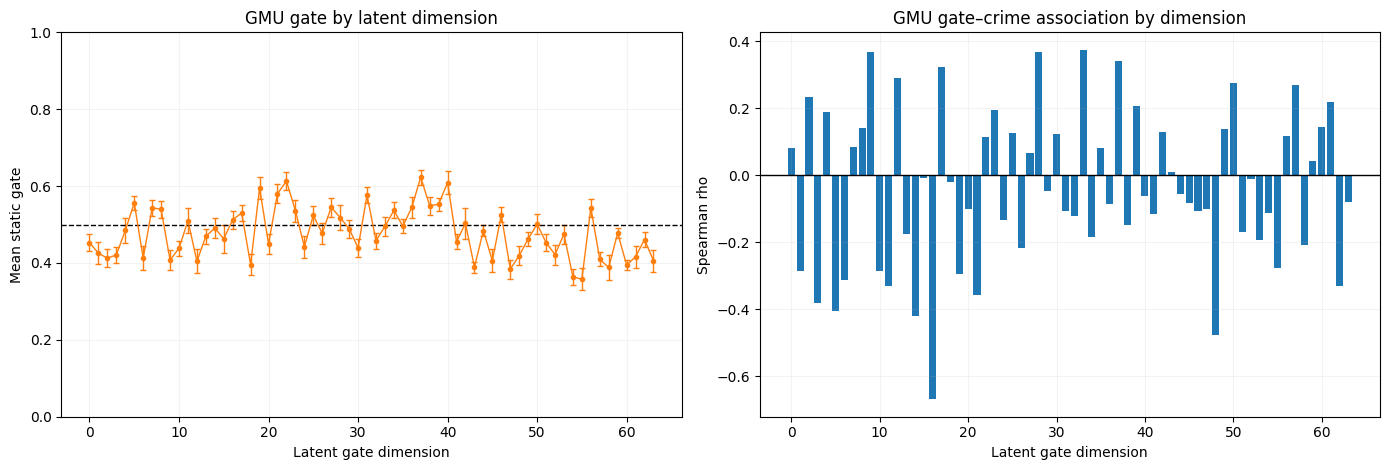

,dimension,mean_gate,std_gate,crime_spearman_rho,crime_spearman_p
16,16,0.512631,0.023562,-0.668815,0.0
48,48,0.418870,0.024370,-0.478443,0.0
14,14,0.490513,0.025313,-0.419521,0.0
5,5,0.556180,0.019093,-0.406613,0.0
3,3,0.420883,0.020101,-0.380111,0.0
33,33,0.494982,0.024609,0.374153,0.0
9,9,0.407738,0.027228,0.366688,0.0
28,28,0.518084,0.031893,0.366112,0.0
21,21,0.580089,0.025357,-0.358241,0.0
37,37,0.623417,0.019556,0.341579,0.0


In [43]:
def safe_correlations(x, matrix, method="spearman"):
    x = np.asarray(x)
    values, pvalues = [], []
    for k in range(matrix.shape[1]):
        y = matrix[:, k]
        if np.std(x) == 0 or np.std(y) == 0:
            values.append(np.nan); pvalues.append(np.nan)
        elif SCIPY_AVAILABLE:
            result = spearmanr(x, y) if method == "spearman" else pearsonr(x, y)
            values.append(float(result[0])); pvalues.append(float(result[1]))
        else:
            values.append(float(np.corrcoef(x, y)[0, 1])); pvalues.append(np.nan)
    return np.asarray(values), np.asarray(pvalues)


crime_values = gmu_explain_frame["input_crime"].to_numpy()
gate_means = gmu_gate_vectors.mean(axis=0)
gate_stds = gmu_gate_vectors.std(axis=0)
gate_rho, gate_p = safe_correlations(crime_values, gmu_gate_vectors, "spearman")
dims = np.arange(gmu_gate_vectors.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].errorbar(dims, gate_means, yerr=gate_stds, marker="o", markersize=3,
                 linewidth=1, capsize=2, color="tab:orange")
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[0].set(title="GMU gate by latent dimension", xlabel="Latent gate dimension",
            ylabel="Mean static gate", ylim=(0, 1))
axes[1].bar(dims, gate_rho, color="tab:blue")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="GMU gate–crime association by dimension", xlabel="Latent gate dimension",
            ylabel="Spearman rho")
for ax in axes: ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_featurewise_gate_specialization.png"), dpi=300, bbox_inches="tight")
plt.show()

gmu_featurewise_gate_stats = pd.DataFrame({
    "dimension": dims, "mean_gate": gate_means, "std_gate": gate_stds,
    "crime_spearman_rho": gate_rho, "crime_spearman_p": gate_p,
})
display(gmu_featurewise_gate_stats.reindex(
    gmu_featurewise_gate_stats.crime_spearman_rho.abs().sort_values(ascending=False).index
).head(10))
gmu_featurewise_gate_stats.to_csv(os.path.join(output_folder, "gmu_featurewise_gate_stats.csv"), index=False)

## E. GMU gate association with input and future crime

Pearson measures linear association and Spearman measures monotonic association. Statistics
use all original node-time cases; quantile bins are used only to make the plot readable.

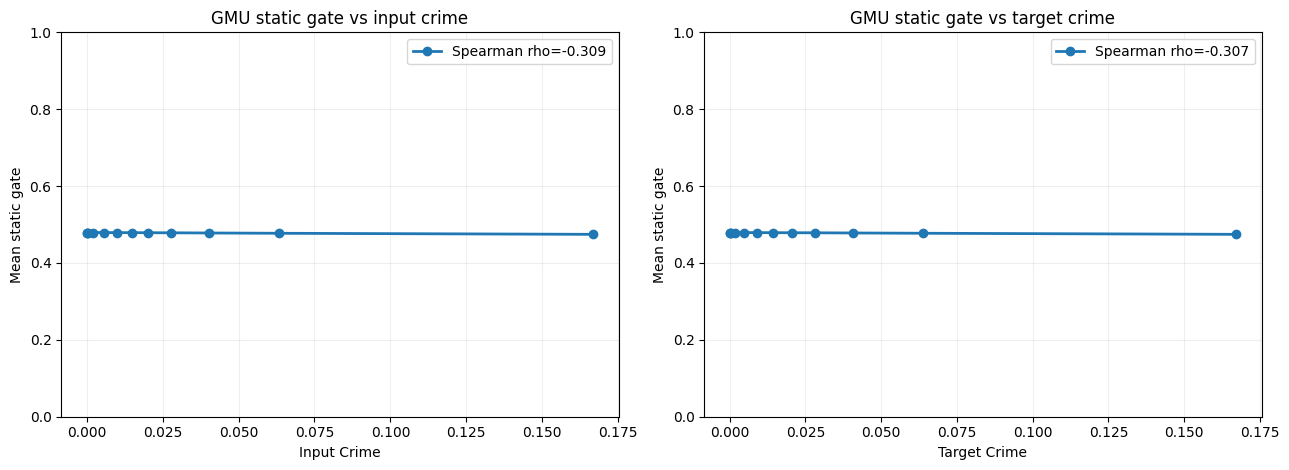

,role,crime_variable,pearson_r,pearson_p,spearman_rho,spearman_p
0,GMU,input_crime,-0.46746,0.0,-0.30938,0.0
1,GMU,target_crime,-0.46474,0.0,-0.30666,0.0


In [44]:
def association_stats(x, y):
    x, y = np.asarray(x), np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {"pearson_r": np.nan, "pearson_p": np.nan,
                "spearman_rho": np.nan, "spearman_p": np.nan}
    if SCIPY_AVAILABLE:
        pr, sr = pearsonr(x, y), spearmanr(x, y)
        return {"pearson_r": float(pr[0]), "pearson_p": float(pr[1]),
                "spearman_rho": float(sr[0]), "spearman_p": float(sr[1])}
    return {"pearson_r": float(np.corrcoef(x, y)[0, 1]), "pearson_p": np.nan,
            "spearman_rho": np.nan, "spearman_p": np.nan}


def binned_summary(frame, x_col, y_col, bins=12):
    work = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work["bin"] = pd.qcut(work[x_col], q=bins, duplicates="drop")
    out = work.groupby("bin", observed=True).agg(
        mean_x=(x_col, "mean"), mean_y=(y_col, "mean"),
        std_y=(y_col, "std"), count=(y_col, "size")
    ).reset_index(drop=True)
    out["ci95"] = 1.96*out["std_y"] / np.sqrt(out["count"].clip(lower=1))
    return out


gmu_association_rows = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, x_col in zip(axes, ["input_crime", "target_crime"]):
    stats = association_stats(gmu_explain_frame[x_col], gmu_explain_frame["gmu_static_gate"])
    gmu_association_rows.append({"role": "GMU", "crime_variable": x_col, **stats})
    summary = binned_summary(gmu_explain_frame, x_col, "gmu_static_gate", bins=12)
    ax.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
    ax.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                    summary["mean_y"]+summary["ci95"], alpha=0.2)
    ax.set(title=f"GMU static gate vs {x_col.replace('_', ' ')}",
           xlabel=x_col.replace("_", " ").title(), ylabel="Mean static gate", ylim=(0, 1))
    ax.legend([f"Spearman rho={stats['spearman_rho']:.3f}"])
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_crime_associations.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_crime_associations = pd.DataFrame(gmu_association_rows)
display(gmu_gate_crime_associations.round(5))
gmu_gate_crime_associations.to_csv(os.path.join(output_folder, "gmu_gate_crime_associations.csv"), index=False)

## F. Effective gated activation contribution

Raw gates do not include the magnitude of `tanh` candidate representations. The effective
static proportion below compares $\|z\odot h_s\|_2$ with
$\|(1-z)\odot h_d\|_2$. It is a pre-GraphConv representation-magnitude diagnostic, not causal importance. Later graph propagation can amplify, suppress, or mix these fused activations.

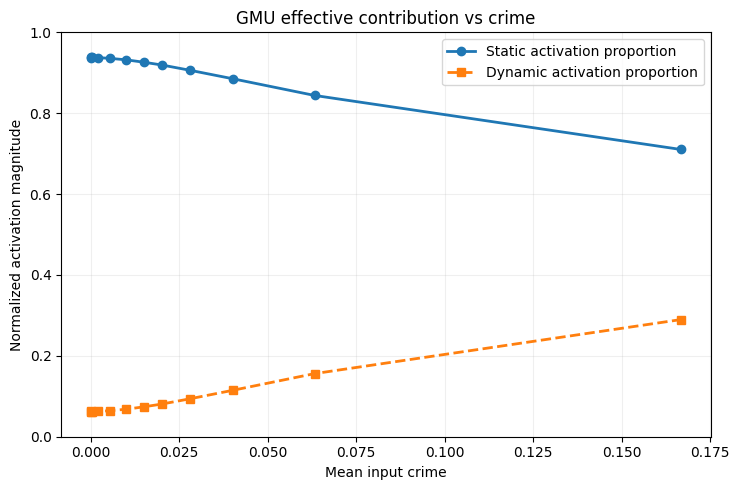

,role,mean_raw_static_gate,mean_effective_static_proportion,mean_effective_dynamic_proportion,gate_vs_effective_pearson
0,single_GMU_gate,0.4784,0.9008,0.0992,0.2063


In [45]:
summary = binned_summary(gmu_explain_frame, "input_crime", "static_activation_proportion", bins=12)
plt.figure(figsize=(7.5, 5))
plt.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2,
         label="Static activation proportion")
plt.plot(summary["mean_x"], 1.0-summary["mean_y"], marker="s", linestyle="--",
         linewidth=2, label="Dynamic activation proportion")
plt.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                 summary["mean_y"]+summary["ci95"], alpha=0.15)
plt.xlabel("Mean input crime")
plt.ylabel("Normalized activation magnitude")
plt.ylim(0, 1)
plt.title("GMU effective contribution vs crime")
plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_effective_activation_contribution.png"), dpi=300, bbox_inches="tight")
plt.show()

gmu_effective_contribution = pd.DataFrame([{
    "role": "single_GMU_gate",
    "mean_raw_static_gate": gmu_explain_frame["gmu_static_gate"].mean(),
    "mean_effective_static_proportion": gmu_explain_frame["static_activation_proportion"].mean(),
    "mean_effective_dynamic_proportion": gmu_explain_frame["dynamic_activation_proportion"].mean(),
    "gate_vs_effective_pearson": association_stats(
        gmu_explain_frame["gmu_static_gate"], gmu_explain_frame["static_activation_proportion"]
    )["pearson_r"],
}])
display(gmu_effective_contribution.round(4))
gmu_effective_contribution.to_csv(os.path.join(output_folder, "gmu_effective_contribution.csv"), index=False)

## G. Self-versus-neighbor gate separation — not applicable

GMU–GNN has one feature-wise GMU gate per node-time case, calculated **before** `GraphConv`. The fused vector is then used by graph propagation. Consequently, this model uses neighborhood information, but it cannot assign one modality balance to the focal-node pathway and another balance to incoming neighbor messages.

M11 can perform that separation because it contains distinct self and neighbor gates inside its message-passing design. Creating two gates here merely for analysis would change GMU–GNN into another architecture. Therefore, M11’s self-versus-neighbor gate comparison is deliberately recorded as **not defined for GMU–GNN**.

## H. Spatial and temporal stability of the single GMU gate

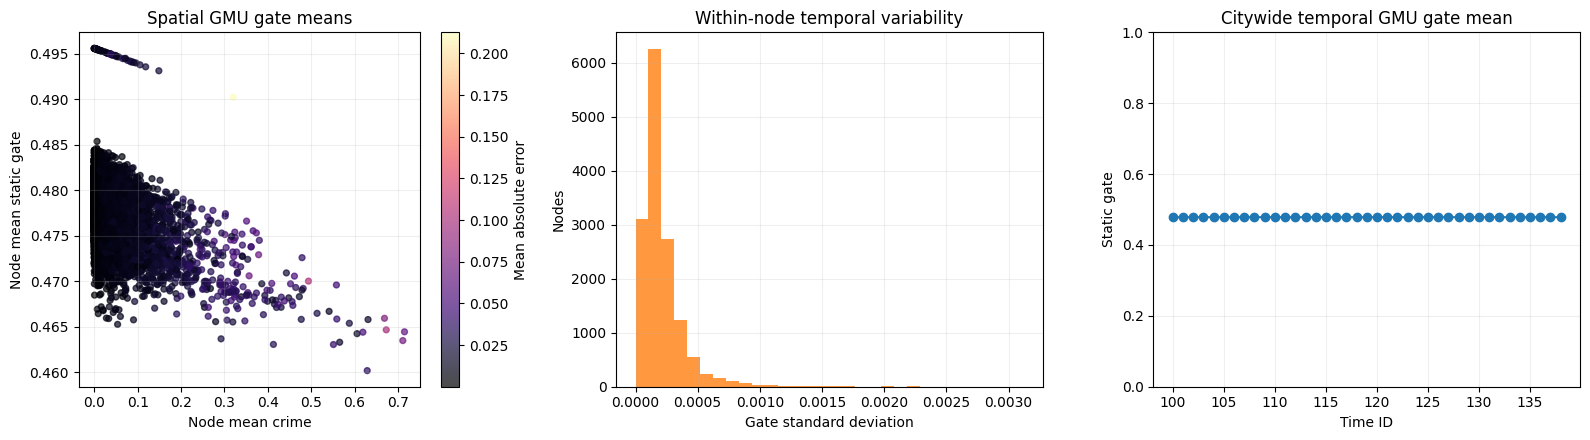

,node_id,gate_mean,gate_std,mean_crime,mean_absolute_error
13759,13759,0.473788,0.003118,0.361775,0.043667
8149,8149,0.472709,0.003053,0.321197,0.050963
2538,2538,0.478033,0.002983,0.227495,0.056592
10708,10708,0.468768,0.002709,0.310790,0.012411
5155,5155,0.465558,0.002678,0.279655,0.012337
1423,1423,0.476379,0.002343,0.285412,0.024893
11888,11888,0.467798,0.002275,0.399450,0.018054
3852,3852,0.474068,0.002232,0.219688,0.008068
6693,6693,0.472780,0.002224,0.244658,0.038103
114,114,0.469197,0.002202,0.267732,0.012710


In [46]:
gmu_node_stability = gmu_explain_frame.groupby("node_id").agg(
    gate_mean=("gmu_static_gate", "mean"), gate_std=("gmu_static_gate", "std"),
    mean_crime=("input_crime", "mean"), mean_absolute_error=("absolute_error", "mean"),
).reset_index()
gmu_time_stability = gmu_explain_frame.groupby("time_id").agg(
    gate_mean=("gmu_static_gate", "mean"), gate_std=("gmu_static_gate", "std"),
    mean_crime=("input_crime", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sc = axes[0].scatter(gmu_node_stability["mean_crime"], gmu_node_stability["gate_mean"],
                     c=gmu_node_stability["mean_absolute_error"], cmap="magma", s=18, alpha=0.7)
fig.colorbar(sc, ax=axes[0], label="Mean absolute error")
axes[0].set(title="Spatial GMU gate means", xlabel="Node mean crime", ylabel="Node mean static gate")
axes[1].hist(gmu_node_stability["gate_std"].dropna(), bins=30, color="tab:orange", alpha=0.8)
axes[1].set(title="Within-node temporal variability", xlabel="Gate standard deviation", ylabel="Nodes")
axes[2].plot(gmu_time_stability["time_id"], gmu_time_stability["gate_mean"], marker="o")
axes[2].set(title="Citywide temporal GMU gate mean", xlabel="Time ID", ylabel="Static gate", ylim=(0, 1))
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_spatial_temporal_gate_stability.png"), dpi=300, bbox_inches="tight")
plt.show()
display(gmu_node_stability.sort_values("gate_std", ascending=False).head(10))
gmu_node_stability.to_csv(os.path.join(output_folder, "gmu_node_gate_stability.csv"), index=False)
gmu_time_stability.to_csv(os.path.join(output_folder, "gmu_time_gate_stability.csv"), index=False)

## I. GMU gate relationship with prediction error

This identifies associations between modality balance and difficult cases. It does not show
that changing the gate would necessarily reduce an error; the intervention test addresses
functional faithfulness more directly.

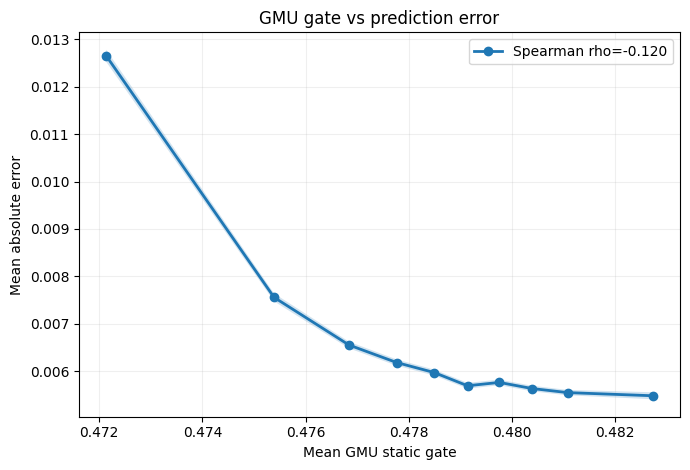

,role,pearson_r,pearson_p,spearman_rho,spearman_p
0,GMU,-0.19739,0.0,-0.11996,0.0


In [47]:
gmu_error_stats = association_stats(
    gmu_explain_frame["gmu_static_gate"], gmu_explain_frame["absolute_error"]
)
summary = binned_summary(gmu_explain_frame, "gmu_static_gate", "absolute_error", bins=10)
plt.figure(figsize=(7, 4.8))
plt.plot(summary["mean_x"], summary["mean_y"], marker="o", linewidth=2)
plt.fill_between(summary["mean_x"], summary["mean_y"]-summary["ci95"],
                 summary["mean_y"]+summary["ci95"], alpha=0.2)
plt.xlabel("Mean GMU static gate"); plt.ylabel("Mean absolute error")
plt.title("GMU gate vs prediction error")
plt.legend([f"Spearman rho={gmu_error_stats['spearman_rho']:.3f}"])
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_error_relationship.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_error_association = pd.DataFrame([{"role": "GMU", **gmu_error_stats}])
display(gmu_gate_error_association.round(5))
gmu_gate_error_association.to_csv(os.path.join(output_folder, "gmu_gate_error_association.csv"), index=False)

## J. Single-gate intervention faithfulness

All trained weights remain fixed while the GMU gate logits are replaced. Fixed probabilities
are strong off-manifold interventions; shuffled logits are often the more credible test
because they preserve the learned logit distribution while breaking assignment to cases.

,intervention,MSE,RMSE,MAE,delta_MSE_vs_learned,relative_MSE_change_percent
0,Learned gate,0.00013,0.01148,0.00670,0.00000,0.00000
1,Balanced gate (0.5),0.00049,0.02217,0.01353,0.00036,272.81441
2,Static-heavy gate (0.95),0.00292,0.05404,0.02511,0.00279,2114.36531
3,Dynamic-heavy gate (0.05),0.00476,0.06902,0.02628,0.00463,3512.84229
4,Shuffled learned gate logits,0.00044,0.02108,0.01304,0.00031,237.13471


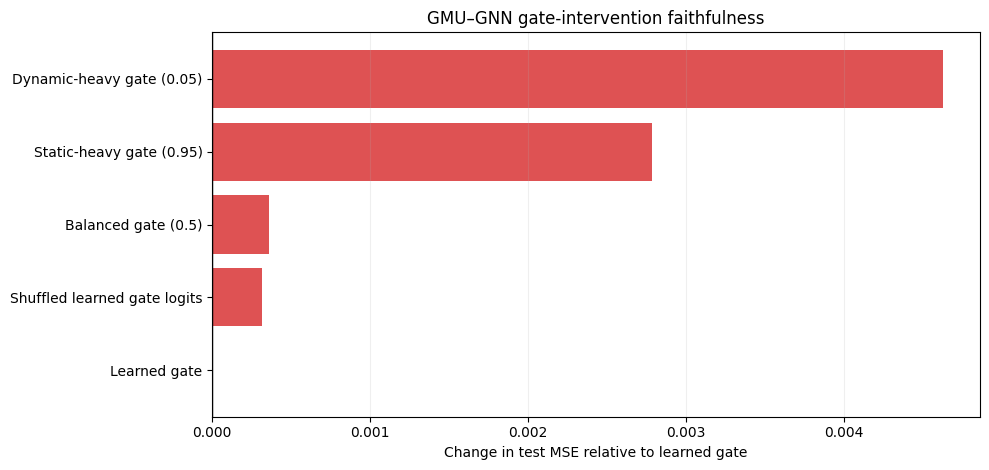

In [48]:
def _constant_logit_hook(probability):
    p = float(np.clip(probability, 1e-4, 1.0-1e-4))
    logit = math.log(p/(1.0-p))
    def hook(module, inputs, output):
        return torch.full_like(output, logit)
    return hook


def _shuffle_logit_hook(random_seed):
    counter = {"value": 0}
    def hook(module, inputs, output):
        generator = torch.Generator(device=output.device)
        generator.manual_seed(random_seed + counter["value"])
        counter["value"] += 1
        flat = output.reshape(-1)
        permutation = torch.randperm(flat.numel(), generator=generator, device=output.device)
        return flat[permutation].reshape_as(output)
    return hook


@contextlib.contextmanager
def gmu_gate_intervention(model, probability=None, shuffle=False, random_seed=42):
    handle = None
    try:
        if shuffle:
            handle = model.gmu.gate_layer.register_forward_hook(_shuffle_logit_hook(random_seed))
        elif probability is not None:
            handle = model.gmu.gate_layer.register_forward_hook(_constant_logit_hook(probability))
        yield
    finally:
        if handle is not None:
            handle.remove()


def evaluate_current_gmu(model, loader, device):
    model.eval(); pred_all, target_all = [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            prediction, _ = model(data.x_static, data.x_dynamic, data.edge_index)
            target = data.y.float().view_as(prediction)
            pred_all.append(prediction.cpu()); target_all.append(target.cpu())
    prediction = torch.cat(pred_all).numpy(); target = torch.cat(target_all).numpy()
    error = prediction-target; mse = float(np.mean(error**2))
    return {"MSE": mse, "RMSE": float(np.sqrt(mse)), "MAE": float(np.mean(np.abs(error)))}


gmu_intervention_specs = [
    ("Learned gate", None, False),
    ("Balanced gate (0.5)", 0.5, False),
    ("Static-heavy gate (0.95)", 0.95, False),
    ("Dynamic-heavy gate (0.05)", 0.05, False),
    ("Shuffled learned gate logits", None, True),
]
gmu_intervention_rows = []
for label, probability, shuffle in gmu_intervention_specs:
    with gmu_gate_intervention(model, probability, shuffle, seed):
        row = evaluate_current_gmu(model, test_loader, device)
    gmu_intervention_rows.append({"intervention": label, **row})
gmu_gate_interventions = pd.DataFrame(gmu_intervention_rows)
gmu_baseline_mse = gmu_gate_interventions.loc[
    gmu_gate_interventions.intervention == "Learned gate", "MSE"
].iloc[0]
gmu_gate_interventions["delta_MSE_vs_learned"] = gmu_gate_interventions["MSE"]-gmu_baseline_mse
gmu_gate_interventions["relative_MSE_change_percent"] = (
    100*gmu_gate_interventions["delta_MSE_vs_learned"]/(gmu_baseline_mse+1e-12)
)
display(gmu_gate_interventions.round(5))

plot_df = gmu_gate_interventions.sort_values("delta_MSE_vs_learned")
plt.figure(figsize=(10, 4.8))
plt.barh(plot_df["intervention"], plot_df["delta_MSE_vs_learned"],
         color=["tab:green" if x <= 0 else "tab:red" for x in plot_df["delta_MSE_vs_learned"]], alpha=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Change in test MSE relative to learned gate")
plt.title("GMU–GNN gate-intervention faithfulness")
plt.grid(axis="x", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_intervention_faithfulness.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_gate_interventions.to_csv(os.path.join(output_folder, "gmu_gate_interventions.csv"), index=False)

## K. Model-agnostic input permutation importance

This returns from latent gates to named socioeconomic features and temporal lags. An increase
in MSE after node-wise permutation indicates reliance by the frozen model. Correlated inputs
can share or redistribute importance, so rankings are not causal effects.

,modality,feature,baseline_MSE,permuted_MSE_mean,permuted_MSE_std,delta_MSE
15,dynamic,crime_lag_1,0.000132,0.001793,1.609345e-07,0.001661
14,dynamic,crime_lag_2,0.000132,0.000809,1.795434e-06,0.000677
13,dynamic,crime_lag_3,0.000132,0.000281,4.555648e-07,0.000149
12,dynamic,crime_lag_4,0.000132,0.000152,6.839711e-08,0.000020
7,static,Estacao_de_metro,0.000132,0.000142,7.146523e-08,0.000010
4,static,menores_de_18_anos_taxa,0.000132,0.000138,1.263395e-07,0.000006
1,static,Renda_media_responsaveis,0.000132,0.000137,1.181703e-07,0.000005
6,static,maiores_de_65_anos_taxa,0.000132,0.000137,8.559542e-08,0.000005
9,static,Terminal_de_onibus,0.000132,0.000136,3.651999e-08,0.000004
8,static,Estacao_de_trem,0.000132,0.000133,3.960484e-08,0.000001


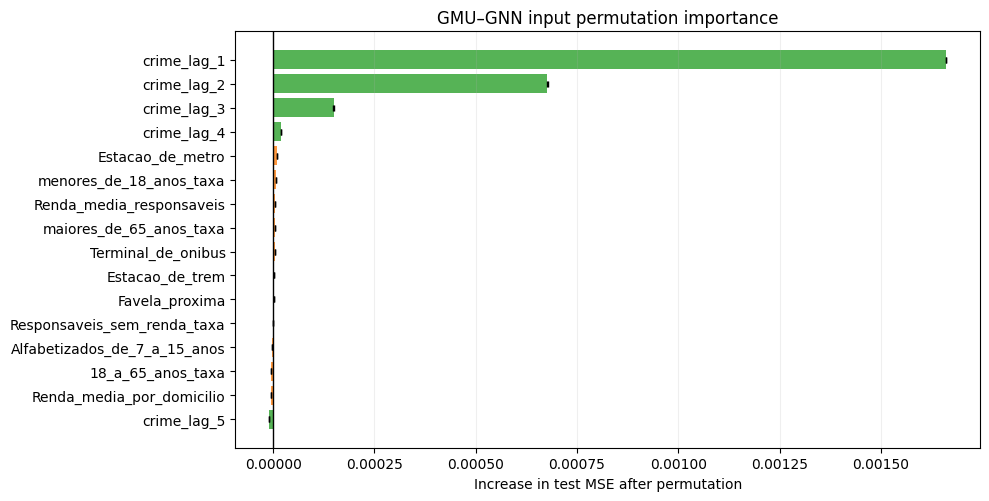

In [49]:
@torch.no_grad()
def gmu_permutation_importance(model, loader, device, static_names=None, repeats=3, random_seed=42):
    model.eval()
    baseline = evaluate_current_gmu(model, loader, device)["MSE"]
    sample = next(iter(loader))
    static_dim, dynamic_dim = sample.x_static.shape[1], sample.x_dynamic.shape[1]
    if static_names is None or len(static_names) != static_dim:
        static_names = [f"static_{i}" for i in range(static_dim)]
    dynamic_names = [f"crime_lag_{dynamic_dim-i}" for i in range(dynamic_dim)]
    rows = []
    for modality, dim, names in [("static", static_dim, static_names),
                                 ("dynamic", dynamic_dim, dynamic_names)]:
        for feature_index in range(dim):
            repeated_mse = []
            for repeat in range(repeats):
                pred_all, target_all = [], []
                generator = torch.Generator(device=device)
                generator.manual_seed(random_seed + 1000*feature_index + 17*repeat +
                                      (0 if modality == "static" else 100000))
                for data in loader:
                    data = data.to(device)
                    xs, xd = data.x_static.clone(), data.x_dynamic.clone()
                    permutation = torch.randperm(xs.shape[0], generator=generator, device=device)
                    if modality == "static": xs[:, feature_index] = xs[permutation, feature_index]
                    else: xd[:, feature_index] = xd[permutation, feature_index]
                    prediction, _ = model(xs, xd, data.edge_index)
                    pred_all.append(prediction.cpu()); target_all.append(data.y.float().view_as(prediction).cpu())
                prediction = torch.cat(pred_all).numpy(); target = torch.cat(target_all).numpy()
                repeated_mse.append(float(np.mean((prediction-target)**2)))
            rows.append({
                "modality": modality, "feature": names[feature_index], "baseline_MSE": baseline,
                "permuted_MSE_mean": np.mean(repeated_mse),
                "permuted_MSE_std": np.std(repeated_mse, ddof=1) if repeats > 1 else 0.0,
                "delta_MSE": np.mean(repeated_mse)-baseline,
            })
    return pd.DataFrame(rows)


static_feature_names = list(static_dt.columns) if len(static_dt.columns) == S else None
gmu_permutation_table = gmu_permutation_importance(
    model, test_loader, device, static_names=static_feature_names, repeats=3, random_seed=seed
)
display(gmu_permutation_table.sort_values("delta_MSE", ascending=False).head(15))
plot_df = gmu_permutation_table.sort_values("delta_MSE", ascending=True)
plt.figure(figsize=(10, max(5, 0.32*len(plot_df))))
plt.barh(plot_df["feature"], plot_df["delta_MSE"], xerr=plot_df["permuted_MSE_std"],
         color=plot_df["modality"].map({"static": "tab:orange", "dynamic": "tab:green"}),
         alpha=0.8, capsize=2)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Increase in test MSE after permutation")
plt.title("GMU–GNN input permutation importance")
plt.grid(axis="x", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_input_permutation_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_permutation_table.to_csv(os.path.join(output_folder, "gmu_input_permutation_importance.csv"), index=False)

## L. Time-cluster bootstrap confidence intervals

The bootstrap resamples complete test windows so all nodes from a selected time remain
together. These intervals capture test-window variation, not random initialization or
training uncertainty; multiple matched seeds are still required.

,quantity,estimate,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_std
0,gate_mean,0.47837,0.47837,0.47838,0.00000
1,effective_static,0.90080,0.90057,0.90105,0.00012
2,gate_crime_spearman,-0.30938,-0.31218,-0.30654,0.00146


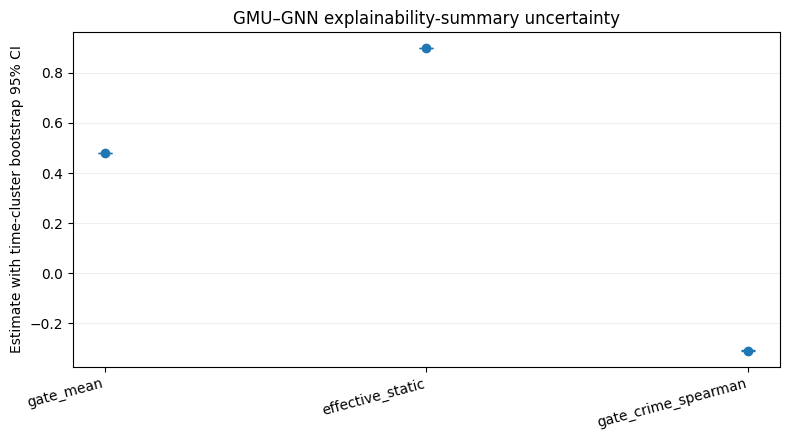

In [50]:
def gmu_cluster_bootstrap(frame, cluster_col="time_id", n_bootstrap=1000, random_seed=42):
    rng = np.random.default_rng(random_seed)
    clusters = frame[cluster_col].drop_duplicates().to_numpy()
    estimates = []
    for _ in range(n_bootstrap):
        sampled = rng.choice(clusters, size=len(clusters), replace=True)
        boot = pd.concat([frame.loc[frame[cluster_col] == c] for c in sampled], ignore_index=True)
        estimates.append({
            "gate_mean": boot["gmu_static_gate"].mean(),
            "effective_static": boot["static_activation_proportion"].mean(),
            "gate_crime_spearman": association_stats(
                boot["input_crime"], boot["gmu_static_gate"]
            )["spearman_rho"],
        })
    samples = pd.DataFrame(estimates)
    point = {
        "gate_mean": frame["gmu_static_gate"].mean(),
        "effective_static": frame["static_activation_proportion"].mean(),
        "gate_crime_spearman": association_stats(
            frame["input_crime"], frame["gmu_static_gate"]
        )["spearman_rho"],
    }
    summary = pd.DataFrame([{
        "quantity": col, "estimate": point[col],
        "bootstrap_ci95_low": samples[col].quantile(0.025),
        "bootstrap_ci95_high": samples[col].quantile(0.975),
        "bootstrap_std": samples[col].std(ddof=1),
    } for col in samples.columns])
    return summary, samples


gmu_bootstrap_summary, gmu_bootstrap_samples = gmu_cluster_bootstrap(
    gmu_explain_frame, n_bootstrap=1000, random_seed=seed
)
display(gmu_bootstrap_summary.round(5))
plt.figure(figsize=(8, 4.5))
x = np.arange(len(gmu_bootstrap_summary))
lower = gmu_bootstrap_summary["estimate"]-gmu_bootstrap_summary["bootstrap_ci95_low"]
upper = gmu_bootstrap_summary["bootstrap_ci95_high"]-gmu_bootstrap_summary["estimate"]
plt.errorbar(x, gmu_bootstrap_summary["estimate"], yerr=np.vstack([lower, upper]),
             fmt="o", capsize=5, linewidth=2)
plt.xticks(x, gmu_bootstrap_summary["quantity"], rotation=15, ha="right")
plt.ylabel("Estimate with time-cluster bootstrap 95% CI")
plt.title("GMU–GNN explainability-summary uncertainty")
plt.grid(axis="y", alpha=0.2); plt.tight_layout()
plt.savefig(os.path.join(output_folder, "gmu_gate_bootstrap_ci.png"), dpi=300, bbox_inches="tight")
plt.show()
gmu_bootstrap_summary.to_csv(os.path.join(output_folder, "gmu_gate_bootstrap_ci.csv"), index=False)

## M. Graph-structure reliance

This analysis tests whether the trained GMU–GNN actually uses neighborhood edges. The learned model is evaluated normally and again with all message-passing edges removed. A performance decrease supports functional reliance on the graph.

This is not a self-versus-neighbor **gate** analysis. It measures the value of graph propagation as a whole. Because the model was trained with edges, edge removal is a post-hoc intervention and should be complemented by a separately trained no-graph baseline for the strongest publication evidence.

,graph_condition,MSE,RMSE,MAE,delta_MSE_vs_graph,relative_MSE_change_percent
0,Learned graph,0.000132,0.011483,0.006704,0.00000,0.00000
1,Edges removed,0.000392,0.019795,0.010703,0.00026,197.16188


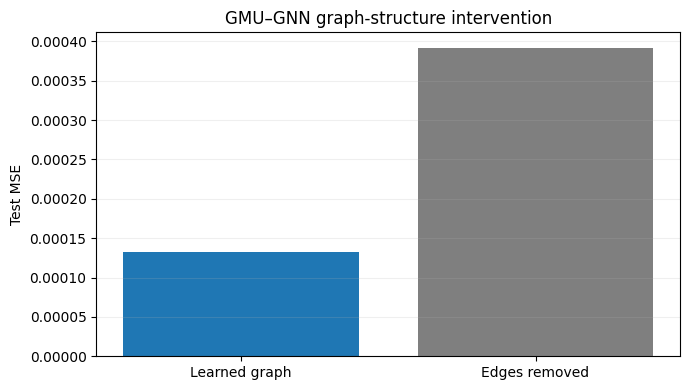

In [51]:
@torch.no_grad()
def evaluate_gmu_gnn_edge_intervention(model, loader, device, remove_edges=False):
    model.eval()
    predictions, targets = [], []

    for data in loader:
        data = data.to(device)
        edge_index = data.edge_index
        if remove_edges:
            edge_index = torch.empty((2, 0), dtype=torch.long, device=device)

        prediction, _ = model(
            data.x_static,
            data.x_dynamic,
            edge_index,
        )
        target = data.y.float().view_as(prediction)
        predictions.append(prediction.cpu())
        targets.append(target.cpu())

    prediction = torch.cat(predictions).numpy()
    target = torch.cat(targets).numpy()
    error = prediction - target
    mse = float(np.mean(error ** 2))
    return {
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "MAE": float(np.mean(np.abs(error))),
    }


gmu_gnn_graph_rows = []
for label, remove_edges in [
    ("Learned graph", False),
    ("Edges removed", True),
]:
    row = evaluate_gmu_gnn_edge_intervention(
        model, test_loader, device, remove_edges=remove_edges
    )
    gmu_gnn_graph_rows.append({"graph_condition": label, **row})

gmu_gnn_graph_intervention = pd.DataFrame(gmu_gnn_graph_rows)
baseline_graph_mse = gmu_gnn_graph_intervention.loc[
    gmu_gnn_graph_intervention["graph_condition"] == "Learned graph", "MSE"
].iloc[0]
gmu_gnn_graph_intervention["delta_MSE_vs_graph"] = (
    gmu_gnn_graph_intervention["MSE"] - baseline_graph_mse
)
gmu_gnn_graph_intervention["relative_MSE_change_percent"] = (
    100.0 * gmu_gnn_graph_intervention["delta_MSE_vs_graph"]
    / (baseline_graph_mse + 1e-12)
)
display(gmu_gnn_graph_intervention.round(6))

plt.figure(figsize=(7, 4))
plt.bar(
    gmu_gnn_graph_intervention["graph_condition"],
    gmu_gnn_graph_intervention["MSE"],
    color=["tab:blue", "tab:gray"],
)
plt.ylabel("Test MSE")
plt.title("GMU–GNN graph-structure intervention")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig(
    os.path.join(output_folder, "gmu_gnn_graph_intervention.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

gmu_gnn_graph_intervention.to_csv(
    os.path.join(output_folder, "gmu_gnn_graph_intervention.csv"), index=False
)


## N. Exportable summary and three-model comparison guidance

Run the cells above before this summary. The exported row uses column names aligned with the original-GMU and M11 summaries. Absent self/neighbor statistics remain explicitly unavailable rather than being filled with artificial values.

For the final comparison:

1. **Original GMU** tests node-level fusion without graph propagation.
2. **GMU–GNN** tests node-level GMU fusion followed by graph propagation.
3. **M11** tests role-specific static/dynamic fusion inside message passing.

Compare prediction metrics across matched seeds first. Then compare gate health, effective activation, gate–crime association, intervention faithfulness and input importance. Treat M11’s separate self/neighbor behavior as an additional architectural capability, not a missing numerical score for the two single-gate GMU baselines.

In [52]:
learned_row = gmu_gate_interventions.query("intervention == 'Learned gate'").iloc[0]
balanced_row = gmu_gate_interventions.query("intervention == 'Balanced gate (0.5)'").iloc[0]
shuffled_row = gmu_gate_interventions.query("intervention == 'Shuffled learned gate logits'").iloc[0]
input_assoc = gmu_gate_crime_associations.query("crime_variable == 'input_crime'").iloc[0]
no_edge_row = gmu_gnn_graph_intervention.query("graph_condition == 'Edges removed'").iloc[0]

gmu_gnn_model_explainability_summary = pd.DataFrame([{
    "model": "GMU–GNN",
    "uses_graph": True,
    "gate_role": "single_pre_graph_fusion_gate",
    "test_MSE": metrics["MSE"],
    "test_RMSE": metrics["RMSE"],
    "test_MAE": metrics["MAE"],
    "test_R2": metrics["R2"],
    "static_only_MSE": static_metrics["MSE"],
    "dynamic_only_MSE": dynamic_metrics["MSE"],
    "static_gate_mean": gmu_explain_frame["gmu_static_gate"].mean(),
    "gate_std_featurewise": gmu_gate_health["global_std"].iloc[0],
    "gate_entropy": gmu_gate_health["mean_entropy_0_to_1"].iloc[0],
    "gate_input_crime_spearman": input_assoc["spearman_rho"],
    "effective_static_proportion": gmu_explain_frame["static_activation_proportion"].mean(),
    "balanced_gate_delta_MSE": balanced_row["MSE"] - learned_row["MSE"],
    "shuffled_gate_delta_MSE": shuffled_row["MSE"] - learned_row["MSE"],
    "edges_removed_delta_MSE": no_edge_row["MSE"] - metrics["MSE"],
    "self_neighbor_analysis_available": False,
}])

display(gmu_gnn_model_explainability_summary.T)
gmu_gnn_model_explainability_summary.to_csv(
    os.path.join(output_folder, "gmu_gnn_professional_model_explainability_summary.csv"),
    index=False,
)


,0
model,GMU–GNN
uses_graph,True
gate_role,single_pre_graph_fusion_gate
test_MSE,0.000132
test_RMSE,0.011483
test_MAE,0.006704
test_R2,0.954551
static_only_MSE,0.003846
dynamic_only_MSE,0.001425
static_gate_mean,0.478373


## Interpretation framework after running the notebook

Use prediction and explanation evidence separately:

1. **Predictive quality:** report MSE, RMSE, MAE and R² across matched seeds.
2. **Fusion benefit:** compare the full model with post-hoc ablations and independently trained unimodal baselines.
3. **Gate health:** a mean near 0.5 is not collapse; inspect variation, entropy, saturation and interventions together.
4. **Conditional behavior:** report gate–crime effect sizes, not p-values alone.
5. **Mechanistic scale:** compare raw gates with effective pre-GraphConv activation proportions.
6. **Faithfulness:** emphasize shuffled-gate degradation because it preserves the learned gate distribution while breaking assignment.
7. **Original-feature evidence:** use permutation importance while acknowledging correlated features.
8. **Graph evidence:** edge-removal degradation indicates reliance on propagation, but a retrained no-graph baseline is stronger evidence.
9. **Uncertainty:** time-cluster bootstrap intervals do not replace 5–10 matched training seeds.

For a fair M11–GMU–GMU–GNN comparison, use identical preprocessing, chronological splits, inductive node partitions, checkpoint-selection rules, hidden dimensions where feasible, optimizer-search policy and random seeds.